In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../src/')
from preprocessing import *
from metrics import *
from models import *
from utils import *
from balanced import *
from plots import *

In [2]:
from IPython.display import Markdown, display

dev_set = pd.read_csv('../data2/WAR_class_dev.csv')
test_set = pd.read_csv('../data2/WAR_class_test.csv')
y_labels = ['Negative WAR', 'Null WAR', 'Positive WAR']

In [3]:

def show_basic_info(dev_set, name):
    display(Markdown(f"### {name}"))
    display(Markdown(f"**Forma del dataset**: {dev_set.shape}"))
    display(Markdown("**Primeras filas del dataset**:"))
    display(dev_set.head())
    display(Markdown("**Información del dataset**:"))
    display(dev_set.info())
    display(Markdown("**Estadísticas descriptivas**:"))
    display(dev_set.describe())
    display(Markdown("**Distribución de clases**:"))
    display(dev_set['war_class'].value_counts(normalize=True))

# show_basic_info(dev_set, "Datos Balanceados (Desarrollo)")


 war_total = 'Wins Above Replacement — how many wins the player adds compared to a "replacement-level" player.
  this will be our target

 mp = minutes played

 poss = possesions in season

 raptor_offense: The player’s offensive Raptor rating — an advanced stat estimating offensive impact per 100 possessions.

 raptor_defense: Defensive Raptor rating — impact on defense per 100 possessions.

 raptor_total: Total Raptor rating — combines offense and defense for an overall impact metric.
 
 pace_impact = Impact on the team’s pace — how much the player influences the speed of the game

In [4]:
# dev_set.drop(columns=["war_class"]).hist(figsize=(20, 15), bins=30)
# plt.tight_layout()
# plt.show()

In [5]:
# corr = dev_set.corr()

# fig, axes = plt.subplots(1, 1, figsize=(10, 8))
# sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', ax=axes)
# plt.tight_layout()
# plt.show()

parecce ser que poss y mp estan altmente correlacionados

In [6]:
# sns.pairplot(dev_set, hue="war_class", diag_kind="kde", markers=["o", "s", "^"],)
# plt.suptitle("Pairplot de variables numéricas", y=1.02)
# plt.show()

In [7]:
# duplicados_dev = dev_set.duplicated().any()
# print(f"¿Hay datos duplicados en dev_set? {duplicados_dev}")

In [8]:
# f,axs = plt.subplots(ncols=2, figsize = (10,3))
# sns.scatterplot(x='pace_impact' , y='war_total',hue='poss', palette='viridis', data=dev_set, s=50, ax=axs[0])
# sns.scatterplot(x='raptor_total' , y='war_total',hue='poss', palette='viridis', data=dev_set, s=50, ax=axs[1])

In [9]:
cut = 500
dev_set['significant_poss'] = (dev_set['poss'] >= cut).astype(int)
dev_set['significant_poss'] = dev_set['significant_poss'].astype('category')

In [10]:
X_train, X_val, y_train, y_val, means, stds = split_and_normalize(dev_set.drop(columns=['war_total']), 'war_class')


Resultados para Análisis Discriminante Lineal (LDA)

Classification Report
              precision    recall  f1-score   support

Negative WAR       0.85      1.00      0.92       375
    Null WAR       0.99      0.72      0.83       512
Positive WAR       0.86      0.99      0.92       470

    accuracy                           0.89      1357
   macro avg       0.90      0.90      0.89      1357
weighted avg       0.90      0.89      0.89      1357


--- Confusion Matrix ---


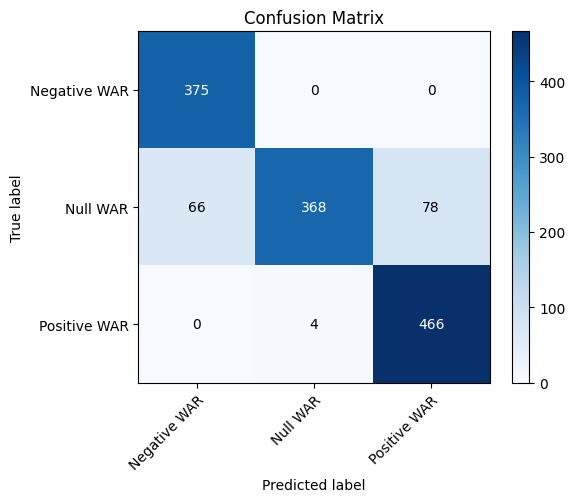

--- Performance Curves  ---
Multi-class case detected. Plotting One-vs-Rest (OvR) curves.
AUC ROC (OvR):
  - Class 'Negative WAR': 0.988
  - Class 'Null WAR': 0.942
  - Class 'Positive WAR': 0.991

AUC PR (OvR):
  - Class 'Negative WAR': 0.919
  - Class 'Null WAR': 0.940
  - Class 'Positive WAR': 0.980


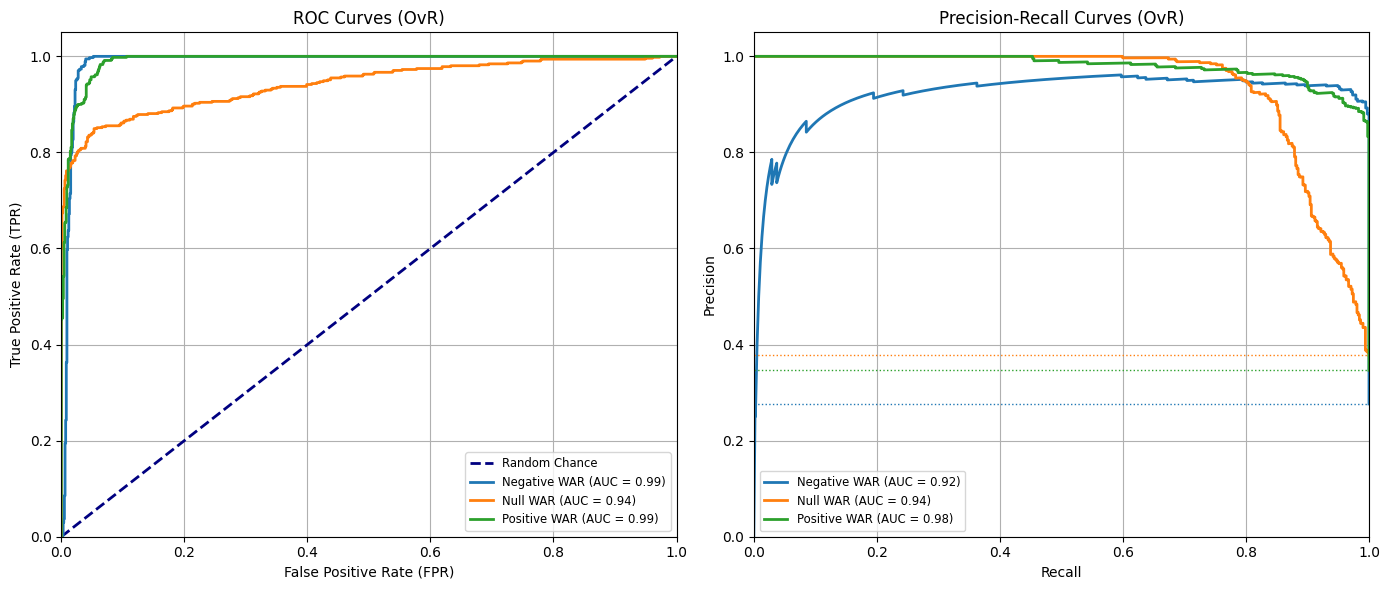

In [11]:
X_train_array = X_train.values
X_val_array = X_val.values
# Entrenar LDA
lda_model = LDA()
lda_model.fit(X_train_array, y_train)

# Evaluar
y_pred_lda = lda_model.predict(X_val_array)
y_proba_lda = lda_model.predict_proba(X_val_array)

# Mostrar métricas
print("\n" + "="*50)
print("Resultados para Análisis Discriminante Lineal (LDA)")
print("="*50)
display_full_metrics(y_val, y_pred_lda, y_proba_lda, lda_model.classes_, y_labels)
print("\n" + "="*50)


Resultados para Regresión Logística Multiclase

Classification Report
              precision    recall  f1-score   support

Negative WAR       0.87      0.99      0.93       375
    Null WAR       0.95      0.80      0.87       512
Positive WAR       0.90      0.97      0.93       470

    accuracy                           0.91      1357
   macro avg       0.91      0.92      0.91      1357
weighted avg       0.91      0.91      0.91      1357


--- Confusion Matrix ---


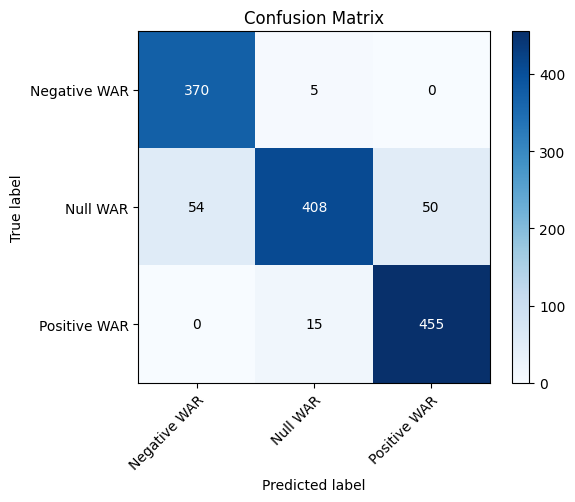

--- Performance Curves  ---
Multi-class case detected. Plotting One-vs-Rest (OvR) curves.
AUC ROC (OvR):
  - Class 'Negative WAR': 0.982
  - Class 'Null WAR': 0.933
  - Class 'Positive WAR': 0.993

AUC PR (OvR):
  - Class 'Negative WAR': 0.886
  - Class 'Null WAR': 0.931
  - Class 'Positive WAR': 0.986


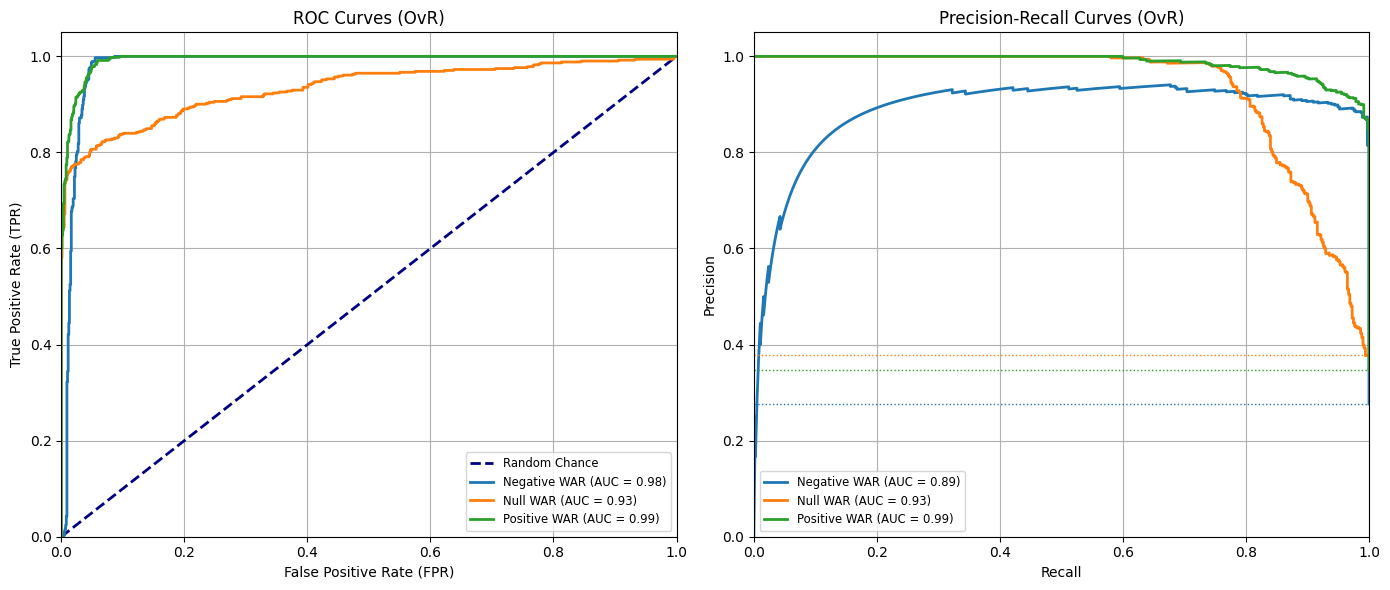


Logistic Regression Coefficients (Mode: multinomial):
  Class '1':
    Feature 0: 0.1047
    Feature 1: 0.2293
    Feature 2: -3.2182
    Feature 3: -0.1542
    Feature 4: 0.9030
    Bias: -0.7472
  Class '2':
    Feature 0: -0.8158
    Feature 1: -1.1057
    Feature 2: 0.4135
    Feature 3: -0.0331
    Feature 4: -0.2272
    Bias: 1.5318
  Class '3':
    Feature 0: 0.7111
    Feature 1: 0.8765
    Feature 2: 2.8047
    Feature 3: 0.1873
    Feature 4: -0.6758
    Bias: -0.7845



In [12]:
# Entrenar Regresión Logística Multiclase con regularización
mlr_model = LogisticRegression(
    learning_rate=0.1,
    n_iterations=1000,
    reg_lambda=0.1  # Parámetro de regularización
)
mlr_model.fit(X_train_array, y_train)

# Evaluar
y_pred_mlr = mlr_model.predict(X_val_array)
y_proba_mlr = mlr_model.predict_proba(X_val_array)

# Mostrar métricas
print("\n" + "="*50)
print("Resultados para Regresión Logística Multiclase")
print("="*50)
display_full_metrics(y_val, y_pred_mlr, y_proba_mlr, mlr_model.classes_, y_labels)
print("\n" + "="*50)
# Mostrar coeficientes para interpretabilidad
mlr_model.print_coefficients()

In [ ]:
import numpy as np
from models import RandomForest
from metrics import f1_score, accuracy_score, display_full_metrics
from preprocessing import create_stratified_k_folds

# Configuraciones seleccionadas manualmente para evaluar
# En lugar de probar todas las combinaciones, elegimos las más prometedoras
configs = [
    # Configuraciones base con diferentes tamaños de bosque
    {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 2, 'max_features': None},
    {'n_estimators': 150, 'max_depth': 10, 'min_samples_split': 2, 'max_features': None},
    
    # Variaciones en profundidad
    {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2, 'max_features': None},
    {'n_estimators': 100, 'max_depth': 5, 'min_samples_split': 2, 'max_features': None},
    
    # Variaciones en características seleccionadas por split
    {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 2, 'max_features': 0.7},
    
    # Configuraciones para prevenir overfitting
    {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 5, 'max_features': 0.7},
    {'n_estimators': 150, 'max_depth': 8, 'min_samples_split': 5, 'max_features': 0.7},
]

# Configuración de la búsqueda
n_folds = 5                              # Número de folds para validación cruzada
random_seed = 42                         # Semilla para reproducibilidad
metric_name = 'weighted_f1'              # Métrica a optimizar

print(f"Iniciando búsqueda de hiperparámetros con {n_folds}-Fold Cross-Validation")
print(f"Total de configuraciones a probar: {len(configs)}")
print(f"Métrica a optimizar: {metric_name}")
print("-" * 60)

# Preparar folds de CV una sola vez (fuera del bucle principal)
cv_folds = create_stratified_k_folds(X_train_array, y_train, k=n_folds, random_state=random_seed)

# Variables para seguimiento
best_avg_score = -1
best_params = None
results = []

# Bucle principal de evaluación de configuraciones
for i, params in enumerate(configs):
    print(f"\nConfig [{i+1}/{len(configs)}]: {params}")
    
    # Evaluación en cada fold
    fold_scores = []
    for fold_idx, (train_idx, val_idx) in enumerate(cv_folds):
        # Obtener datos para este fold
        X_train_fold, y_train_fold = X_train_array[train_idx], y_train[train_idx]
        X_val_fold, y_val_fold = X_train_array[val_idx], y_train[val_idx]
        
        # Entrenar modelo con la configuración actual
        rf_model = RandomForest(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            min_samples_split=params['min_samples_split'],
            max_features=params['max_features'],
            random_state=random_seed
        )
        rf_model.fit(X_train_fold, y_train_fold)
        
        # Evaluar en fold de validación
        y_pred_fold = rf_model.predict(X_val_fold)
        score = f1_score(y_val_fold, y_pred_fold, average='weighted', zero_division=0)
        fold_scores.append(score)
    
    # Calcular y almacenar resultados de esta configuración
    avg_score = np.mean(fold_scores)
    std_score = np.std(fold_scores)
    results.append({
        'params': params, 
        'avg_score': avg_score,
        'std_score': std_score, 
        'fold_scores': fold_scores
    })
    
    print(f"  Score: {avg_score:.4f} ± {std_score:.4f}")
    
    # Actualizar mejor configuración si corresponde
    if avg_score > best_avg_score:
        best_avg_score = avg_score
        best_params = params
        print(f"  ¡Nueva mejor configuración encontrada!")

# Ordenar resultados por puntuación promedio (descendente)
sorted_results = sorted(results, key=lambda x: x['avg_score'], reverse=True)

# Mostrar resultados finales
print("\n" + "="*60)
print("RESULTADOS DE LA BÚSQUEDA DE HIPERPARÁMETROS")
print("="*60)
print(f"Mejor configuración: {best_params}")
print(f"Mejor score ({metric_name}): {best_avg_score:.4f}")

# Mostrar top 3 configuraciones
print("\nTop 3 configuraciones:")
for i, res in enumerate(sorted_results[:3]):
    print(f"{i+1}. Score: {res['avg_score']:.4f} ± {res['std_score']:.4f} | Params: {res['params']}")

# Opcional: Visualización de resultados
# import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
scores = [r['avg_score'] for r in sorted_results]
plt.plot(range(len(scores)), scores, 'o-')
plt.xlabel('Configuración (ordenada por rendimiento)')
plt.ylabel(f'Score ({metric_name})')
plt.title('Rendimiento de las configuraciones evaluadas')
plt.grid(True)
plt.tight_layout()
plt.show()

Iniciando búsqueda de hiperparámetros con 5-Fold Cross-Validation
Total de configuraciones a probar: 7
Métrica a optimizar: weighted_f1
------------------------------------------------------------

Config [1/7]: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 2, 'max_features': None}


In [ ]:
# Entrenar el modelo final con los mejores parámetros en TODO el set de entrenamiento
print("\nEntrenando el modelo final con la mejor configuración...")
final_rf_model = RandomForest(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params.get('min_samples_leaf', 1),
    max_features=best_params.get('max_features'),
    criterion=best_params['criterion'],
    random_state=random_seed
)
# Entrenar en el conjunto completo de entrenamiento original
final_rf_model.fit(X_train_array, y_train)

# Evaluar el modelo final en el conjunto de validación HELD-OUT (el que no se usó en CV)
print("\nEvaluando el modelo final en el set de validación HELD-OUT...")
y_pred_final = final_rf_model.predict(X_val_array)
y_proba_final = final_rf_model.predict_proba(X_val_array) # Necesario para display_multiclass_metrics

# Mostrar métricas
print("\n" + "="*50)
print("Resultados para Random Forest con mejores hiperparámetros")
print("="*50)
display_full_metrics(y_val, y_pred_final, y_proba_final, y_labels)
print("\n" + "="*50)

plot_feature_importance(
    final_rf_model,
    feature_names=X_train.columns,
    n_features=10,
    title="Importancia de las características (Random Forest)",
    figsize=(10, 6)
)
plt.show()

In [ ]:
# # 1. Verificar las clases
# print("Clases en los datos:", np.unique(y_train))

# # 2. Entrenamiento del Random Forest
# rf_model = RandomForest(
#     n_estimators=10
#     max_depth=10,
#     min_samples_split=2,
#     criterion='entropy',
#     random_state=42
# )
# rf_model.fit(X_train_array, y_train)

# # 3. Evaluación
# y_pred_rf = rf_model.predict(X_val_array)
# y_proba_rf = rf_model.predict_proba(X_val_array)

# # 4. Verificar resultados
# print("Shape de y_proba_rf:", y_proba_rf.shape)
# print("Clases predichas:", np.unique(y_pred_rf))

# # 5. Mostrar métricas
# print("\n" + "="*50)
# print("Resultados para Random Forest con clases 1, 2, 3")
# print("="*50)
# display_multiclass_metrics(y_val, y_pred_rf, y_proba_rf, rf_model.classes_)
# # Mostrar importancia de características


In [ ]:
metrics_lda = calculate_metrics(y_val, y_pred_lda, y_proba_lda)
metrics_mlr = calculate_metrics(y_val, y_pred_mlr, y_proba_mlr)
metrics_rf = calculate_metrics(y_val, y_pred_final, y_proba_final)

# Crear tabla comparativa
comparison_df = pd.DataFrame([metrics_lda, metrics_mlr, metrics_rf])
comparison_df.set_index('Modelo', inplace=True)

# Mostrar tabla
print("\n" + "="*50)
print("Comparación de Modelos")
print("="*50)
display(comparison_df) # Display the DataFrame directly

# Gráfico comparativo de métricas
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
metrics_to_plot = ['Accuracy', 'F1-Score', 'AUC-ROC', 'AUC-PR']

for ax, metric in zip(axes.flatten(), metrics_to_plot):
    comparison_df[metric].plot(kind='bar', ax=ax, color=['skyblue', 'salmon', 'lightgreen'])
    ax.set_title(metric)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# # Si tenemos características 2D o podemos reducir la dimensionalidad (PCA manual)
# # Podemos visualizar las fronteras de decisión

# # Ejemplo con las dos características más importantes del Random Forest
# if len(feature_names) >= 2:
#     # Seleccionar las dos características más importantes
#     importances = best_rf.feature_importances_
#     top_two_idx = np.argsort(importances)[-2:]
#     X_train_2d = X_train_array[:, top_two_idx]
#     X_val_2d = X_val_array[:, top_two_idx]
    
#     # Entrenar modelos en el subespacio 2D para visualización
#     print("\nVisualización de fronteras de decisión en espacio 2D")
    
#     # LDA en 2D
#     lda_2d = LDA()
#     lda_2d.fit(X_train_2d, y_train)
#     plot_decision_boundary(lda_2d, X_val_2d, y_val, title="Frontera de Decisión - LDA")
    
#     # Regresión Logística en 2D
#     mlr_2d = MultinomialLogisticRegression(learning_rate=0.1, n_iter=1000)
#     mlr_2d.fit(X_train_2d, y_train)
#     plot_decision_boundary(mlr_2d, X_val_2d, y_val, title="Frontera de Decisión - Regresión Logística")
    
#     # Random Forest en 2D
#     rf_2d = RandomForest(n_estimators=50, max_depth=5, criterion='entropy')
#     rf_2d.fit(X_train_2d, y_train)
#     plot_decision_boundary(rf_2d, X_val_2d, y_val, title="Frontera de Decisión - Random Forest")

In [ ]:
# Identificar el mejor modelo basado en F1-Score (balance entre precision y recall)
best_model_idx = comparison_df['F1-Score'].idxmax()
best_model_name = best_model_idx
best_model_metrics = comparison_df.loc[best_model_idx]

print("\n" + "="*50)
print("Mejor Modelo Seleccionado")
print("="*50)
print(f"Modelo: {best_model_name}")
print(f"F1-Score: {best_model_metrics['F1-Score']:.4f}")
print(f"Accuracy: {best_model_metrics['Accuracy']:.4f}")
print(f"AUC-ROC: {best_model_metrics['AUC-ROC']:.4f}")
print(f"AUC-PR: {best_model_metrics['AUC-PR']:.4f}")

# Guardar el mejor modelo
if best_model_name == 'LDA':
    best_model = lda_model
elif best_model_name == 'Regresión Logística':
    best_model = mlr_model
else:
    best_model = best_rf

# Si queremos guardar el modelo para producción
# from utils import save_model
# save_model(best_model, 'mejor_modelo.pkl')